# 🍅 Мультидетекция ингредиентов — Faster R-CNN + ResNet50-FPN

**Важно:** Среда выполнения → Изменить тип среды выполнения → GPU (T4)

### Оптимизации:
- Нормализация и объединение классов (синонимы, локальные названия, мусорные теги)
- Mixed Precision Training (AMP) — ускорение ~1.5–2x на T4
- Warm-up + Cosine Annealing LR schedule
- Gradient Clipping
- Early Stopping
- Weighted Sampling — балансировка редких классов
- Анализ распределения классов до и после нормализации

## Ячейка 1 — Установка зависимостей

In [1]:
!pip install -q roboflow

import torch
print(f'PyTorch:       {torch.__version__}')
print(f'CUDA доступна: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:           {torch.cuda.get_device_name(0)}')
    print(f'VRAM:          {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 35.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 96.8 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
PyTorch:       2.10.0+cu128
CUDA доступна: True
GPU:           Tesla T4
VRAM:          15.6 GB


## Ячейка 2 — Скачивание датасетов с Roboflow

In [2]:
import os
from roboflow import Roboflow

# !! Вставьте свой API ключ с roboflow.com (бесплатно)
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
API_KEY = user_secrets.get_secret("ROBOFLOW")

rf = Roboflow(api_key=API_KEY)

# Датасет 1: ingredients-agbcq (wonkeun-jung-vfcwn)
# Классы-примеры: 0=broccoli, 1=peas, 32=celery
proj1 = rf.workspace("wonkeun-jung-vfcwn").project("ingredients-agbcq")
ds1 = proj1.version(1).download("coco", location="/kaggle/working/datasets/ds1")

# Датасет 2: aicook (Karel Cornelis)
proj2 = rf.workspace("karel-cornelis-q2qqg").project("aicook-lcv4d")
ds2 = proj2.version(1).download("coco", location="/kaggle/working/datasets/ds2")

print('Все датасеты скачаны!')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/datasets/ds1 in coco:: 100%|██████████| 8874/8874 [00:01<00:00, 5791.21it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/datasets/ds2 in coco:: 100%|██████████| 524/524 [00:00<00:00, 2617.11it/s]

Все датасеты скачаны!


## Ячейка 3 — Нормализация классов

In [3]:
import re

# =============================================================
# ПРАВИЛА НОРМАЛИЗАЦИИ КЛАССОВ
# =============================================================
# None = удалить аннотацию (мусорные теги)
# Порядок важен: более специфичные правила — выше
# =============================================================

# Мусорные/технические классы — удаляем
TRASH_CLASSES = {
    '1-6lq6', 'food-ingredients', 'ingredients', 'food ingredients',
    'ingredient', 'food', 'misc', 'other', 'unknown',
}

# ---------------------------------------------------------------
# DS1 (ingredients-agbcq): маппинг по ЧИСЛОВЫМ ID категорий.
# В этом датасете числовые id категорий несут семантику (0..N),
# поэтому мы сначала разрешаем имя через числовой id, а потом
# через обычный текстовый маппинг.
#
# Известные классы (id -> нормализованное имя):
#   0  -> broccoli
#   1  -> peas
#   32 -> celery        ("salary" в датасете — опечатка)
#
# Остальные id этого датасета будут разрешены через текстовый маппинг ниже.
# Если нужно явно указать ещё классы — добавьте сюда.
# ---------------------------------------------------------------
# DS1_ID_TO_CLASS = {
#     0:  'broccoli',
#     1:  'peas',
#     32: 'celery',
#     # добавьте сюда любые другие явные переопределения для ds1
# }

# ---------------------------------------------------------------
# Основной маппинг: нормализованное сырое название -> финальный класс
# ---------------------------------------------------------------
CLASS_NORMALIZATION = {
    "'":  'broccoli',
    '1':  'peas',
    '32': 'celery',
    # --- Брокколи и капустные ---
    'broccoli':                 'broccoli',

    # --- Сельдерей ---
    'celery':                   'celery',
    'salary':                   'celery',     # опечатка в ds1
    'celeriac':                 'celery',

    # --- Синонимы и варианты написания ---
    'okra':                     'okra',
    'bhindi':                   'okra',
    'pumpkin':                  'pumpkin',
    'farsi':                    'pumpkin',
    'lemon':                    'lemon',
    'nimbu':                    'lemon',
    'lime':                     'lime',
    'kagati':                   'lime',
    'coriander':                'coriander',
    'dhaniya':                  'coriander',
    'cilantro':                 'coriander',
    'sweet potato':             'sweet_potato',
    'sweet_potato':             'sweet_potato',
    'suthuni':                  'sweet_potato',
    'mushrooms':                'mushroom',
    'mushroom':                 'mushroom',
    'egg':                      'egg',
    'eggs':                     'egg',
    'strawberry':               'strawberry',
    'strawberries':             'strawberry',

    # --- Шпинат ---
    'spinach':                  'spinach',
    'palak':                    'spinach',
    'palungo':                  'spinach',
    'indian spinach':           'spinach',
    'nepali spinach':           'spinach',

    # --- Зелёный лук ---
    'spring onion':             'spring_onion',
    'spring_onion':             'spring_onion',
    'onion leaves':             'spring_onion',
    'green onion':              'spring_onion',
    'scallion':                 'spring_onion',

    # --- Листовая зелень (укрупнённая группа) ---
    'bethu ko saag':            'leafy_greens',
    'farsi ko munta':           'leafy_greens',
    'garden cress':             'leafy_greens',
    'chamsur ko saag':          'leafy_greens',
    'rayo ko saag':             'leafy_greens',
    'tori ko saag':             'leafy_greens',
    'moringa leaves':           'leafy_greens',
    'sajyun ko munta':          'leafy_greens',
    'stinging nettle':          'leafy_greens',
    'sisnu':                    'leafy_greens',
    'fiddlehead ferns':         'leafy_greens',
    'niguro':                   'leafy_greens',
    'lettuce':                  'leafy_greens',
    'kale':                     'leafy_greens',
    'chard':                    'leafy_greens',

    # --- Чечевица / Дал ---
    'black lentils':            'lentils',
    'green lentils':            'lentils',
    'red lentils':              'lentils',
    'yellow lentils':           'lentils',
    'lentils':                  'lentils',
    'lentil':                   'lentils',
    'rahar ko daal':            'lentils',
    'dal':                      'lentils',
    'daal':                     'lentils',

    # --- Фасоль / Бобовые ---
    'beans':                    'beans',
    'bean':                     'beans',
    'black beans':              'beans',
    'red beans':                'beans',
    'broad beans':              'beans',
    'bakullo':                  'beans',
    'long beans':               'beans',
    'bodi':                     'beans',
    'green beans':              'beans',
    'green_beans':              'beans',
    'kidney beans':             'beans',

    # --- Горох / Нут ---
    'green peas':               'peas',
    'garden peas':              'peas',
    'pea':                      'peas',
    'peas':                     'peas',
    'chickpeas':                'peas',
    'chickpea':                 'peas',
    'chick peas':               'peas',

    # --- Соя ---
    'soyabean':                 'soybeans',
    'bhatmas':                  'soybeans',
    'green soyabean':           'soybeans',
    'hariyo bhatmas':           'soybeans',
    'soybean':                  'soybeans',
    'soybeans':                 'soybeans',
    'edamame':                  'soybeans',

    # --- Горькие/бугристые кабачки ---
    'bitter gourd':             'bitter_gourd',
    'bitter_gourd':             'bitter_gourd',
    'pointed gourd':            'bitter_gourd',
    'chuche karela':            'bitter_gourd',
    'karela':                   'bitter_gourd',

    # --- Кабачковые / Сквош ---
    'ash gourd':                'gourd',
    'kubhindo':                 'gourd',
    'bottle gourd':             'gourd',
    'lauka':                    'gourd',
    'chayote':                  'gourd',
    'iskus':                    'gourd',
    'snake gourd':              'gourd',
    'chichindo':                'gourd',
    'sponge gourd':             'gourd',
    'ghiraula':                 'gourd',
    'gourd':                    'gourd',
    'zucchini':                 'gourd',
    'courgette':                'gourd',
    'squash':                   'gourd',

    # --- Баклажан ---
    'brinjal':                  'eggplant',
    'eggplant':                 'eggplant',
    'green brinjal':            'eggplant',
    'aubergine':                'eggplant',

    # --- Перцы ---
    'bell pepper':              'bell_pepper',
    'bell_pepper':              'bell_pepper',
    'capsicum':                 'bell_pepper',
    'sweet pepper':             'bell_pepper',
    'chili pepper':             'chili_pepper',
    'chili_pepper':             'chili_pepper',
    'khursani':                 'chili_pepper',
    'akabare khursani':         'chili_pepper',
    'long pepper':              'chili_pepper',
    'small pepper':             'chili_pepper',
    'small_pepper':             'chili_pepper',
    'hot pepper':               'chili_pepper',
    'jalapeno':                 'chili_pepper',
    'chilli':                   'chili_pepper',
    'chili':                    'chili_pepper',
    'pepper':                   'chili_pepper',

    # --- Мясо ---
    'chicken':                  'chicken',
    'chicken breast':           'chicken',
    'chicken_breast':           'chicken',
    'chicken gizzards':         'chicken',
    'beef':                     'beef',
    'ground beef':              'beef',
    'ground_beef':              'beef',
    'minced meat':              'beef',
    'buff meat':                'beef',
    'mutton':                   'mutton',
    'lamb':                     'mutton',
    'pork':                     'pork',

    # --- Рис и лапша ---
    'rice':                     'rice',
    'chamal':                   'rice',
    'beaten rice':              'rice',
    'chiura':                   'rice',
    'noodle':                   'noodles',
    'noodles':                  'noodles',
    'chowmein noodles':         'noodles',
    'thukpa noodles':           'noodles',
    'pasta':                    'noodles',
    'flour':                    'flour_grain',
    'wheat':                    'flour_grain',
    'wheat flour':              'flour_grain',

    # --- Корнеплоды ---
    'potato':                   'potato',
    'potatoes':                 'potato',
    'radish':                   'radish_turnip',
    'turnip':                   'radish_turnip',
    'beetroot':                 'radish_turnip',
    'beet':                     'radish_turnip',
    'cassava':                  'taro_cassava',
    'ghar tarul':               'taro_cassava',
    'taro root':                'taro_cassava',
    'taro':                     'taro_cassava',
    'pidalu':                   'taro_cassava',
    'yam':                      'taro_cassava',

    # --- Распространённые овощи ---
    'tomato':                   'tomato',
    'tomatoes':                 'tomato',
    'onion':                    'onion',
    'onions':                   'onion',
    'garlic':                   'garlic',
    'ginger':                   'ginger',
    'carrot':                   'carrot',
    'carrots':                  'carrot',
    'cabbage':                  'cabbage',
    'cauliflower':              'cauliflower',
    'cucumber':                 'cucumber',
    'corn':                     'corn',
    'maize':                    'corn',
    'apple':                    'apple',
    'banana':                   'banana',
    'orange':                   'orange',
    'mango':                    'mango',
    'fish':                     'fish',
    'shrimp':                   'shrimp',
    'prawn':                    'shrimp',
    'oil':                      'oil',
    'butter':                   'butter',
    'cheese':                   'cheese',
    'milk':                     'milk',
    'yogurt':                   'yogurt',
    'curd':                     'yogurt',
    'salt':                     'salt',
    'sugar':                    'sugar',
    'turmeric':                 'turmeric',
    'cumin':                    'cumin',
    'bread':                    'bread',
}


def normalize_class_name(raw_name, cat_id=None, ds_name=None):
    """
    Нормализует название класса:
    1. Для ds1 (ingredients-agbcq) — сначала проверяем числовой ID в DS1_ID_TO_CLASS.
    2. lowercase + strip + удаление локальных суффиксов вида -слово-
    3. Ищем маппинг в CLASS_NORMALIZATION
    4. Неизвестный класс — оставляем очищенное название
    5. Мусорный тег — возвращаем None

    Параметры:
      raw_name — оригинальное имя категории из JSON
      cat_id   — числовой id категории (передаётся при обработке ds1)
      ds_name  — имя датасета ('ds1', 'ds2', ...)
    """
    # --- Шаг 0: числовой маппинг для ds1 ---
    # if ds_name == 'ds1' and cat_id is not None and cat_id in DS1_ID_TO_CLASS:
    #     return DS1_ID_TO_CLASS[cat_id]

    name = raw_name.lower().strip()

    # --- Шаг 1: мусорные теги ---
    if name in TRASH_CLASSES:
        return None

    # --- Шаг 2: удаляем локальные приписки (-bhindi-, -farsi- и т.п.) ---
    cleaned = re.sub(r'\\s*-[^-]+-\\s*', ' ', name).strip()
    cleaned = re.sub(r'\\s+', ' ', cleaned)

    # --- Шаг 3: прямой маппинг ---
    if cleaned in CLASS_NORMALIZATION:
        return CLASS_NORMALIZATION[cleaned]
    if name in CLASS_NORMALIZATION:
        return CLASS_NORMALIZATION[name]

    # --- Шаг 4: частичное совпадение ---
    for key, target in CLASS_NORMALIZATION.items():
        if key in cleaned or key in name:
            return target

    # --- Шаг 5: неизвестный класс — оставляем ---
    return cleaned.replace(' ', '_')


# ── Быстрое тестирование ──────────────────────────────────────
test_cases = [
    # (raw_name, cat_id, ds_name, expected)
    ("'",          None,    'ds1', 'broccoli'),      # числовой id ds1
    ('1',              None,    'ds1', 'peas'),           # числовой id ds1
    ('32',            None,   'ds1', 'celery'),         # числовой id ds1
    ('salary',            None, 'ds2', 'celery'),         # текстовый маппинг (ds2)
    ('okra -bhindi-',     None, 'ds2', 'okra'),
    ('pumpkin -farsi-',   None, 'ds2', 'pumpkin'),
    ('palak -indian spinach-', None, 'ds2', 'spinach'),
    ('black lentils',     None, 'ds2', 'lentils'),
    ('bell pepper',       None, 'ds2', 'bell_pepper'),
    ('1-6lq6',            None, 'ds2', None),
    ('food-ingredients',  None, 'ds2', None),
    ('chicken breast',    None, 'ds2', 'chicken'),
    ('akabare khursani',  None, 'ds2', 'chili_pepper'),
    ('ghar tarul',        None, 'ds2', 'taro_cassava'),
    ('tomato',            None, 'ds2', 'tomato'),
]
print('Тест нормализации:')
all_ok = True
for raw, cid, dsn, expected in test_cases:
    result = normalize_class_name(raw, cat_id=cid, ds_name=dsn)
    ok = result == expected
    all_ok = all_ok and ok
    status = '✓' if ok else '✗'
    print(f'  {status} ds={dsn} id={cid} "{raw}" -> "{result}" (ожидалось: "{expected}")')
print(f'Итог: {"все тесты прошли ✓" if all_ok else "ЕСТЬ ОШИБКИ ✗"}')

Тест нормализации:
  ✓ ds=ds1 id=None "'" -> "broccoli" (ожидалось: "broccoli")
  ✓ ds=ds1 id=None "1" -> "peas" (ожидалось: "peas")
  ✓ ds=ds1 id=None "32" -> "celery" (ожидалось: "celery")
  ✓ ds=ds2 id=None "salary" -> "celery" (ожидалось: "celery")
  ✓ ds=ds2 id=None "okra -bhindi-" -> "okra" (ожидалось: "okra")
  ✓ ds=ds2 id=None "pumpkin -farsi-" -> "pumpkin" (ожидалось: "pumpkin")
  ✓ ds=ds2 id=None "palak -indian spinach-" -> "spinach" (ожидалось: "spinach")
  ✓ ds=ds2 id=None "black lentils" -> "lentils" (ожидалось: "lentils")
  ✓ ds=ds2 id=None "bell pepper" -> "bell_pepper" (ожидалось: "bell_pepper")
  ✓ ds=ds2 id=None "1-6lq6" -> "None" (ожидалось: "None")
  ✓ ds=ds2 id=None "food-ingredients" -> "None" (ожидалось: "None")
  ✓ ds=ds2 id=None "chicken breast" -> "chicken" (ожидалось: "chicken")
  ✓ ds=ds2 id=None "akabare khursani" -> "chili_pepper" (ожидалось: "chili_pepper")
  ✓ ds=ds2 id=None "ghar tarul" -> "taro_cassava" (ожидалось: "taro_cassava")
  ✓ ds=ds2 id=None "t

## Ячейка 4 — Объединение датасетов с нормализацией классов

In [4]:
import json
import shutil
from pathlib import Path
from collections import Counter

# ── Порог фильтрации редких классов ──────────────────────────
# Классы с количеством аннотаций ниже этого порога будут
# полностью удалены из объединённого датасета.
# Рекомендуется: 50 для небольших датасетов, 100–200 для больших.
MIN_ANNOTATIONS = 50

def load_coco_json(path):
    with open(path) as f:
        return json.load(f)

def find_coco_json(base_dir, split='train'):
    candidates = [
        Path(base_dir) / split / '_annotations.coco.json',
        Path(base_dir) / f'{split}/_annotations.coco.json',
        Path(base_dir) / f'{split}.json',
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    raise FileNotFoundError(f'COCO JSON не найден в {base_dir} для split={split}')


def merge_coco_datasets(ds_paths, output_dir, split='train'):
    output_dir = Path(output_dir)
    img_output = output_dir / split / 'images'
    img_output.mkdir(parents=True, exist_ok=True)

    loaded_datasets = []
    raw_class_counter = Counter()   # статистика ДО нормализации

    for ds_path, ds_name in ds_paths:
        try:
            json_path = find_coco_json(ds_path, split)
            data = load_coco_json(json_path)
            img_dir = Path(json_path).parent
            for cat in data['categories']:
                raw_class_counter[cat['name'].lower().strip()] += 1
            loaded_datasets.append((data, img_dir, ds_name))
        except FileNotFoundError as e:
            print(f'  Пропускаем {ds_name}/{split}: {e}')

    if not loaded_datasets:
        return None, {}, Counter()

    # ── Шаг 1: собираем потенциальные финальные классы ───────
    all_final_classes = set()
    for data, _, ds_name in loaded_datasets:
        for cat in data['categories']:
            # Передаём числовой id и имя датасета для ds1
            normalized = normalize_class_name(
                cat['name'],
                cat_id=cat.get('id'),
                ds_name=ds_name,
            )
            if normalized is not None:
                all_final_classes.add(normalized)

    # ── Шаг 2: первый проход — считаем аннотации на класс ────
    # Нужно знать реальное количество аннотаций ДО построения финального маппинга,
    # чтобы отфильтровать редкие классы.
    prelim_counter = Counter()
    for data, img_dir, ds_name in loaded_datasets:
        local_cat_to_norm = {}
        for cat in data['categories']:
            normalized = normalize_class_name(
                cat['name'], cat_id=cat.get('id'), ds_name=ds_name
            )
            local_cat_to_norm[cat['id']] = normalized

        for ann in data['annotations']:
            x, y, w, h = ann['bbox']
            if w <= 0 or h <= 0:
                continue
            norm = local_cat_to_norm.get(ann['category_id'])
            if norm is not None:
                prelim_counter[norm] += 1

    # ── Шаг 3: фильтруем редкие классы ───────────────────────
    rare_classes = {cls for cls, cnt in prelim_counter.items() if cnt < MIN_ANNOTATIONS}
    if rare_classes:
        print(f'[{split}] Удаляем {len(rare_classes)} классов с < {MIN_ANNOTATIONS} аннотаций:')
        for cls in sorted(rare_classes):
            print(f'       - {cls}: {prelim_counter[cls]} аннотаций')

    valid_classes = all_final_classes - rare_classes
    sorted_classes = sorted(valid_classes)
    global_cat_map = {name: idx + 1 for idx, name in enumerate(sorted_classes)}

    merged = {
        'images': [],
        'annotations': [],
        'categories': [
            {'id': v, 'name': k, 'supercategory': 'ingredient'}
            for k, v in global_cat_map.items()
        ]
    }

    global_img_id = 0
    global_ann_id = 0
    removed_trash = 0
    removed_rare = 0
    norm_class_counter = Counter()

    # ── Шаг 4: второй проход — строим объединённый датасет ───
    for data, img_dir, ds_name in loaded_datasets:
        # Строим маппинг: локальный cat_id -> финальный глобальный id (или None)
        local_cat_to_global = {}
        for cat in data['categories']:
            normalized = normalize_class_name(
                cat['name'], cat_id=cat.get('id'), ds_name=ds_name
            )
            if normalized is None:
                local_cat_to_global[cat['id']] = None          # мусорный тег
            elif normalized in rare_classes:
                local_cat_to_global[cat['id']] = 'RARE'        # редкий класс
            else:
                local_cat_to_global[cat['id']] = global_cat_map[normalized]

        old_to_new_img = {}
        for img in data['images']:
            global_img_id += 1
            old_to_new_img[img['id']] = global_img_id

            src = img_dir / img['file_name']
            new_name = f'{ds_name}_{global_img_id:06d}.jpg'
            dst = img_output / new_name
            if src.exists() and not dst.exists():
                shutil.copy2(src, dst)

            merged['images'].append({
                'id': global_img_id,
                'file_name': new_name,
                'width': img['width'],
                'height': img['height'],
            })

        for ann in data['annotations']:
            x, y, w, h = ann['bbox']
            if w <= 0 or h <= 0:
                continue

            final_cat_id = local_cat_to_global.get(ann['category_id'])
            if final_cat_id is None:
                removed_trash += 1
                continue
            if final_cat_id == 'RARE':
                removed_rare += 1
                continue

            global_ann_id += 1
            for name, gid in global_cat_map.items():
                if gid == final_cat_id:
                    norm_class_counter[name] += 1
                    break

            merged['annotations'].append({
                'id': global_ann_id,
                'image_id': old_to_new_img[ann['image_id']],
                'category_id': final_cat_id,
                'bbox': ann['bbox'],
                'area': w * h,
                'iscrowd': ann.get('iscrowd', 0),
            })

    ann_path = output_dir / split / '_annotations.coco.json'
    with open(ann_path, 'w') as f:
        json.dump(merged, f)

    print(f'[{split}] Изображений:  {len(merged["images"])}')
    print(f'[{split}] Аннотаций:    {len(merged["annotations"])}')
    print(f'[{split}]   удалено мусорных: {removed_trash}')
    print(f'[{split}]   удалено редких:   {removed_rare}  (< {MIN_ANNOTATIONS} аннотаций)')
    print(f'[{split}] Классов до нормализации:   {len(raw_class_counter)}')
    print(f'[{split}] Классов после нормализации: {len(prelim_counter)}')
    print(f'[{split}] Классов после фильтрации:   {len(global_cat_map)}')

    return merged, global_cat_map, norm_class_counter


DS_PATHS = [
    ('/kaggle/working/datasets/ds1', 'ds1'),   # ingredients-agbcq
    ('/kaggle/working/datasets/ds2', 'ds2'),   # aicook
]

print('Объединяем train...')
train_data, CLASS_MAP, TRAIN_CLASS_COUNTS = merge_coco_datasets(
    DS_PATHS, '/kaggle/working/merged', split='train'
)
print('\\nОбъединяем valid...')
val_data, _, _ = merge_coco_datasets(
    DS_PATHS, '/kaggle/working/merged', split='valid'
)

NUM_CLASSES = len(CLASS_MAP) + 1  # +1 background
print(f'\\nNUM_CLASSES = {NUM_CLASSES}')

with open('/kaggle/working/class_map.json', 'w') as f:
    json.dump(CLASS_MAP, f, ensure_ascii=False, indent=2)
print('class_map.json сохранён')

Объединяем train...
[train] Удаляем 49 классов с < 50 аннотаций:
       - -: 2 аннотаций
       - apricot: 4 аннотаций
       - biscuit: 1 аннотаций
       - cake: 1 аннотаций
       - cake_roll: 3 аннотаций
       - candy: 1 аннотаций
       - cherry: 2 аннотаций
       - coffee: 28 аннотаций
       - cookie: 6 аннотаций
       - dairy: 1 аннотаций
       - dates: 2 аннотаций
       - fennel: 6 аннотаций
       - fish: 2 аннотаций
       - grape: 3 аннотаций
       - grapefruit: 2 аннотаций
       - green-salad: 1 аннотаций
       - guacamole: 10 аннотаций
       - hash_brown: 6 аннотаций
       - jam: 2 аннотаций
       - juice: 2 аннотаций
       - ketchup: 1 аннотаций
       - kiwi: 8 аннотаций
       - liquor: 3 аннотаций
       - lobster_tail: 20 аннотаций
       - marmelade: 21 аннотаций
       - mayonaise: 43 аннотаций
       - mint: 1 аннотаций
       - mustard: 1 аннотаций
       - nuts: 1 аннотаций
       - olive: 1 аннотаций
       - parsley: 2 аннотаций
       - pickles: 2

## Ячейка 5 — Анализ распределения классов

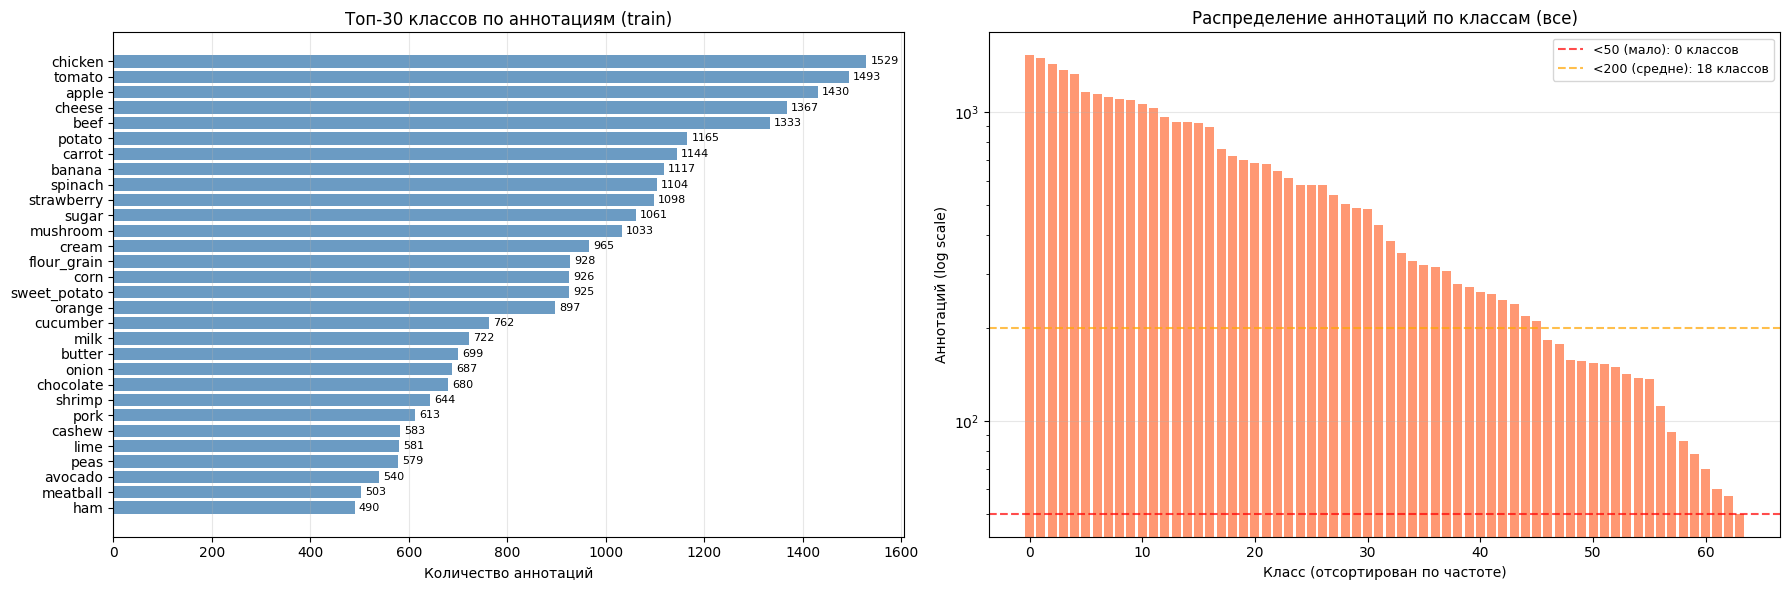

Статистика по аннотациям на класс:
  Медиана:     406
  Среднее:     541
  Мин:         50
  Макс:        1529
  Классов < 50 аннотаций:  0
  Классов < 200 аннотаций: 18


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

if TRAIN_CLASS_COUNTS:
    sorted_counts = sorted(TRAIN_CLASS_COUNTS.items(), key=lambda x: x[1], reverse=True)
    classes, counts = zip(*sorted_counts)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # График 1: топ-30 классов по количеству аннотаций
    top_n = min(30, len(classes))
    ax1 = axes[0]
    bars = ax1.barh(classes[:top_n][::-1], counts[:top_n][::-1], color='steelblue', alpha=0.8)
    ax1.set_xlabel('Количество аннотаций')
    ax1.set_title(f'Топ-{top_n} классов по аннотациям (train)')
    ax1.bar_label(bars, padding=3, fontsize=8)
    ax1.grid(axis='x', alpha=0.3)

    # График 2: log-scale распределение всех классов (длинный хвост)
    ax2 = axes[1]
    ax2.bar(range(len(counts)), sorted(counts, reverse=True), color='coral', alpha=0.8)
    ax2.set_yscale('log')
    ax2.set_xlabel('Класс (отсортирован по частоте)')
    ax2.set_ylabel('Аннотаций (log scale)')
    ax2.set_title('Распределение аннотаций по классам (все)')
    ax2.grid(axis='y', alpha=0.3)

    # Линии для ориентира
    for threshold, color, label in [(50, 'red', '<50 (мало)'), (200, 'orange', '<200 (средне)')]:
        n_below = sum(1 for c in counts if c < threshold)
        ax2.axhline(threshold, color=color, linestyle='--', alpha=0.7,
                    label=f'{label}: {n_below} классов')
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('/kaggle/working/class_distribution.png', dpi=150)
    plt.show()

    # Печатаем статистику
    counts_arr = np.array(list(TRAIN_CLASS_COUNTS.values()))
    print(f'Статистика по аннотациям на класс:')
    print(f'  Медиана:     {np.median(counts_arr):.0f}')
    print(f'  Среднее:     {np.mean(counts_arr):.0f}')
    print(f'  Мин:         {counts_arr.min()}')
    print(f'  Макс:        {counts_arr.max()}')
    print(f'  Классов < 50 аннотаций:  {(counts_arr < 50).sum()}')
    print(f'  Классов < 200 аннотаций: {(counts_arr < 200).sum()}')

## Ячейка 6 — Dataset, Weighted Sampler и DataLoader

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2


def get_transforms(train=True):
    if train:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.1),
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
            A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, p=0.4),
            A.RandomScale(scale_limit=0.25, p=0.4),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.3),
            A.GaussNoise(var_limit=(5, 30), p=0.2),
            A.MotionBlur(blur_limit=3, p=0.1),
            # Случайное кадрирование — модель видит разные части изображения
            A.PadIfNeeded(min_height=512, min_width=512, border_mode=0, value=(0, 0, 0), always_apply=True),
            A.RandomCrop(height=512, width=512, p=0.3),
            A.Resize(640, 640),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(
            format='coco', label_fields=['labels'], min_visibility=0.3, clip=True
        ))
    else:
        return A.Compose([
            A.Resize(640, 640),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(
            format='coco', label_fields=['labels'], min_visibility=0.3,
        ))


class IngredientDataset(Dataset):
    def __init__(self, img_dir, ann_file, transforms=None):
        self.img_dir = Path(img_dir)
        self.transforms = transforms

        with open(ann_file) as f:
            coco = json.load(f)

        self.imgs = {img['id']: img for img in coco['images']}
        self.img_ids = list(self.imgs.keys())

        self.anns = {}
        for ann in coco['annotations']:
            self.anns.setdefault(ann['image_id'], []).append(ann)

        self.img_class_counts = []
        for iid in self.img_ids:
            c = Counter(ann['category_id'] for ann in self.anns.get(iid, []))
            self.img_class_counts.append(c)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_meta = self.imgs[img_id]
        img_path = self.img_dir / 'images' / img_meta['file_name']

        image = np.array(Image.open(img_path).convert('RGB'))
        img_h, img_w = image.shape[:2]

        anns = self.anns.get(img_id, [])
        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann['bbox']
            if w > 0 and h > 0:
                x_min = max(0.0, float(x))
                y_min = max(0.0, float(y))
                x_max = min(float(img_w), float(x + w))
                y_max = min(float(img_h), float(y + h))
                w_clipped = x_max - x_min
                h_clipped = y_max - y_min
                if w_clipped > 0 and h_clipped > 0:
                    boxes.append([x_min, y_min, w_clipped, h_clipped])
                    labels.append(ann['category_id'])

        if not boxes:
            boxes, labels = [[0, 0, 1, 1]], [0]

        if self.transforms:
            t = self.transforms(image=image, bboxes=boxes, labels=labels)
            image, boxes, labels = t['image'], t['bboxes'], t['labels']

        if boxes:
            bt = torch.tensor(boxes, dtype=torch.float32)
            bt[:, 2] = bt[:, 0] + bt[:, 2]
            bt[:, 3] = bt[:, 1] + bt[:, 3]
        else:
            bt = torch.zeros((0, 4), dtype=torch.float32)

        target = {
            'boxes':    bt,
            'labels':   torch.tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([img_id]),
        }
        return image, target


def build_weighted_sampler(dataset, class_counts_map):
    total_ann = sum(class_counts_map.values())
    class_freq = {cls: cnt / total_ann for cls, cnt in class_counts_map.items()}
    class_weight = {cls: 1.0 / freq for cls, freq in class_freq.items()}

    sample_weights = []
    for img_cls_counter in dataset.img_class_counts:
        if img_cls_counter:
            w = max(class_weight.get(cls_id, 1.0) for cls_id in img_cls_counter)
        else:
            w = 1.0
        sample_weights.append(w)

    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )


def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = IngredientDataset(
    '/kaggle/working/merged/train',
    '/kaggle/working/merged/train/_annotations.coco.json',
    transforms=get_transforms(train=True)
)
val_dataset = IngredientDataset(
    '/kaggle/working/merged/valid',
    '/kaggle/working/merged/valid/_annotations.coco.json',
    transforms=get_transforms(train=False)
)

id_to_name = {v: k for k, v in CLASS_MAP.items()}
class_counts_by_id = {CLASS_MAP[name]: count for name, count in TRAIN_CLASS_COUNTS.items()}
sampler = build_weighted_sampler(train_dataset, class_counts_by_id)

# batch_size=2 даёт стабильнее градиенты при большом числе классов
# accumulate_steps=4 — эффективный batch 8 при экономии памяти
BATCH_SIZE = 2
ACCUMULATE_STEPS = 4

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=2, collate_fn=collate_fn, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=2, shuffle=False,
    num_workers=2, collate_fn=collate_fn, pin_memory=True
)

print(f'Train: {len(train_dataset)} изображений, {len(train_loader)} батчей')
print(f'Val:   {len(val_dataset)} изображений, {len(val_loader)} батчей')

# Диагностика датасета
val_img_ids = set(val_dataset.img_ids)
train_img_ids = set(train_dataset.img_ids)
print(f'\nПересечение train/val по image_id: {len(val_img_ids & train_img_ids)} изображений')

# Классы только в train (нет в val — модель не может их валидировать)
train_classes = set()
val_classes = set()
for iid in train_dataset.img_ids:
    for ann in train_dataset.anns.get(iid, []):
        train_classes.add(ann['category_id'])
for iid in val_dataset.img_ids:
    for ann in val_dataset.anns.get(iid, []):
        val_classes.add(ann['category_id'])

only_in_train = train_classes - val_classes
only_in_val = val_classes - train_classes
print(f'Классов только в train (нет в val): {len(only_in_train)}')
print(f'Классов только в val (нет в train): {len(only_in_val)}')
if only_in_val:
    names = [id_to_name.get(c, str(c)) for c in only_in_val]
    print(f'  → {names[:10]}')


ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
Argument(s) 'var_limit' are not valid for transform GaussNoise
Argument(s) 'value, always_apply' are not valid for transform PadIfNeeded


Train: 6722 изображений, 3361 батчей
Val:   1497 изображений, 749 батчей

Пересечение train/val по image_id: 1497 изображений
Классов только в train (нет в val): 31
Классов только в val (нет в train): 9
  → ['69', '71', 'bitter_melon', '73', '72', '74', '78', '79', '83']


## ⏯️ Продолжение обучения с чекпоинта

Если сессия прервалась — просто **запустите все ячейки заново**.  
Ячейка 7 автоматически найдёт `best_model.pth` на Google Drive и продолжит обучение.

**Переменные для управления:**
- `RESUME_CHECKPOINT` — путь к `.pth` файлу (`best_model.pth` или `last_checkpoint.pth`)  
- `NUM_EPOCHS` — суммарное количество эпох (не добавочное!). Например, прошло 12 → поставьте 50  
- Чтобы начать с нуля: `RESUME_CHECKPOINT = None`  

**Что сохраняется в чекпоинте:**
- Веса модели
- Состояние оптимизатора (momentum, adaptive lr)
- Состояние GradScaler (AMP)
- Состояние LR scheduler
- История train_loss / val_score
- Номер эпохи


## Ячейка 7 — Модель и оптимизатор

In [7]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def build_model(num_classes):
    # V2 — улучшенная версия с лучшей точностью на малых объектах
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn_v2(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = build_model(NUM_CLASSES)
model.to(DEVICE)

# ─────────────────────────────────────────────────────────────
# Оптимизатор: SGD с momentum лучше AdamW для Faster R-CNN
# (классический выбор из оригинальной статьи и torchvision примеров)
# ─────────────────────────────────────────────────────────────
# Сначала разморозим только head, backbone заморозим на первые эпохи
def set_backbone_trainable(model, trainable: bool):
    for name, p in model.named_parameters():
        if 'backbone' in name:
            p.requires_grad = trainable

# Первые WARMUP_EPOCHS — обучаем только head (backbone заморожен)
set_backbone_trainable(model, trainable=False)

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005,
    momentum=0.9,
    weight_decay=5e-4
)

NUM_EPOCHS = 50        # суммарное число эпох
WARMUP_EPOCHS = 5      # первые N эпох — только head, backbone заморожен
UNFREEZE_EPOCH = 5     # с этой эпохи размораживаем backbone с меньшим LR

# StepLR: каждые 15 эпох делим LR на 5
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[20, 35, 50], gamma=0.2
)

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# ─────────────────────────────────────────────────────────────
# ЗАГРУЗКА ЧЕКПОИНТА
# ─────────────────────────────────────────────────────────────

CHECKPOINT_DIR = '/kaggle/working/checkpoints2'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

RESUME_CHECKPOINT = f'{CHECKPOINT_DIR}/best_model.pth'  # None → начать с нуля

START_EPOCH = 0
best_val_score = 0
history = {'train_loss': [], 'val_score': [], 'lr': []}

if RESUME_CHECKPOINT and os.path.exists(RESUME_CHECKPOINT):
    print(f'▶ Загружаем чекпоинт: {RESUME_CHECKPOINT}')
    ckpt = torch.load(RESUME_CHECKPOINT, map_location=DEVICE)

    model.load_state_dict(ckpt['model_state_dict'])
    START_EPOCH = ckpt['epoch'] + 1
    best_val_score = ckpt.get('val_score', 0)
    if 'history' in ckpt:
        history = ckpt['history']

    # При продолжении — backbone уже разморожен (если прошли WARMUP_EPOCHS)
    if START_EPOCH >= UNFREEZE_EPOCH:
        set_backbone_trainable(model, trainable=True)
        optimizer = torch.optim.SGD([
            {'params': [p for n,p in model.named_parameters() if 'backbone' in n and p.requires_grad], 'lr': 0.001},
            {'params': [p for n,p in model.named_parameters() if 'backbone' not in n and p.requires_grad], 'lr': 0.005},
        ], momentum=0.9, weight_decay=5e-4)
        scheduler = torch.optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=[20, 35, 50], gamma=0.2
        )

    if 'optimizer_state_dict' in ckpt:
        try:
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        except Exception as e:
            print(f'  Optimizer state не загружен (изменилась архитектура): {e}')

    if 'scaler_state_dict' in ckpt:
        scaler.load_state_dict(ckpt['scaler_state_dict'])

    # Перематываем scheduler
    for _ in range(START_EPOCH):
        scheduler.step()

    print(f'  ✓ Продолжаем с эпохи {START_EPOCH + 1}  (лучший score = {best_val_score:.4f})')
else:
    print('Чекпоинт не найден — начинаем обучение с нуля')

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Параметров: {total:,} всего, {trainable:,} обучаемых (backbone заморожен на первые {WARMUP_EPOCHS} эпох)')


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 197MB/s]  


Чекпоинт не найден — начинаем обучение с нуля
Параметров: 43,594,403 всего, 16,739,939 обучаемых (backbone заморожен на первые 5 эпох)


`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.


## Ячейка 8 — Обучение с AMP, Early Stopping и логированием

## Ячейка 8б — Диагностика переобучения (запускать после обучения)

In [ ]:
import time
from collections import defaultdict
import torch
import torch.distributed as dist # [DDP] Импорт библиотеки для распределенного обучения

def train_one_epoch(model, optimizer, scaler, loader, device, epoch, accumulate_steps=4):
    model.train()
    total_loss = 0
    loss_components = defaultdict(float)
    start = time.time()
    optimizer.zero_grad()

    for i, (images, targets) in enumerate(loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            losses = losses / accumulate_steps  # нормируем для аккумуляции

        scaler.scale(losses).backward()

        if (i + 1) % accumulate_steps == 0 or (i + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += losses.item() * accumulate_steps
        for k, v in loss_dict.items():
            loss_components[k] += v.item()

        if (i + 1) % 25 == 0:
            elapsed = time.time() - start
            lr_now = optimizer.param_groups[-1]['lr']
            # [DDP] Выводим логи только на главном процессе (rank == 0)
            if not dist.is_initialized() or dist.get_rank() == 0:
                print(f'  [{i+1}/{len(loader)}] loss={losses.item()*accumulate_steps:.4f} '
                      f'lr={lr_now:.2e} ({elapsed:.0f}s)')

    avg_loss = total_loss / len(loader)
    
    # [DDP] Синхронизируем и усредняем train_loss со всех видеокарт для одинаковой истории
    if dist.is_initialized():
        loss_t = torch.tensor(avg_loss, dtype=torch.float32, device=device)
        dist.all_reduce(loss_t, op=dist.ReduceOp.SUM)
        avg_loss = loss_t.item() / dist.get_world_size()

    return avg_loss, {k: v / len(loader) for k, v in loss_components.items()}


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    scores_sum, total_dets = 0, 0
    for images, _ in loader:
        images = [img.to(device) for img in images]
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            preds = model(images)
        for pred in preds:
            hc = pred['scores'][pred['scores'] > 0.5]
            scores_sum += hc.sum().item()
            total_dets += len(hc)
            
    # [DDP] Собираем результаты детекции со всех GPU в общую сумму
    if dist.is_initialized():
        stats = torch.tensor([scores_sum, total_dets], dtype=torch.float64, device=device)
        dist.all_reduce(stats, op=dist.ReduceOp.SUM)
        scores_sum, total_dets = stats[0].item(), stats[1].item()

    avg = scores_sum / total_dets if total_dets > 0 else 0
    return avg, total_dets


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.counter = 0
        self.should_stop = False

    def step(self, metric):
        if self.best is None or metric > self.best + self.min_delta:
            self.best = metric
            self.counter = 0
        else:
            self.counter += 1
            # [DDP] Выводим предупреждение только на главном процессе
            if not dist.is_initialized() or dist.get_rank() == 0:
                print(f'  EarlyStopping: {self.counter}/{self.patience} без улучшения')
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


# ─────────────────────────────────────────────────────────────
# ОСНОВНОЙ ЦИКЛ
# ─────────────────────────────────────────────────────────────
early_stop = EarlyStopping(patience=10, min_delta=0.001)
early_stop.best = best_val_score if best_val_score > 0 else None

# [DDP] Флаг главного процесса для управления выводом и сохранениями
is_main_process = not dist.is_initialized() or dist.get_rank() == 0

if is_main_process:
    print(f'Начинаем с эпохи {START_EPOCH + 1}, всего {NUM_EPOCHS} эпох')

for epoch in range(START_EPOCH, NUM_EPOCHS):

    # [DDP] Обязательно: задаем эпоху сэмплеру, чтобы данные перемешивались на каждом GPU
    if hasattr(train_loader.sampler, 'set_epoch'):
        train_loader.sampler.set_epoch(epoch)

    # Размораживаем backbone после UNFREEZE_EPOCH
    if epoch == UNFREEZE_EPOCH and START_EPOCH < UNFREEZE_EPOCH:
        if is_main_process:
            print(f'\n🔓 Эпоха {epoch+1}: размораживаем backbone с LR=0.001')
        
        # [DDP] model.named_parameters() работает корректно даже внутри обертки DDP
        set_backbone_trainable(model, trainable=True)
        optimizer = torch.optim.SGD([
            {'params': [p for n,p in model.named_parameters() if 'backbone' in n], 'lr': 0.001},
            {'params': [p for n,p in model.named_parameters() if 'backbone' not in n], 'lr': 0.005},
        ], momentum=0.9, weight_decay=5e-4)
        scheduler = torch.optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=[20, 35, 50], gamma=0.2
        )
        # Прокручиваем scheduler до текущей эпохи
        for _ in range(epoch):
            scheduler.step()

    if is_main_process:
        print(f'\n=== Epoch {epoch+1}/{NUM_EPOCHS} '
              f'(LR={optimizer.param_groups[-1]["lr"]:.2e}) ===')

    train_loss, components = train_one_epoch(
        model, optimizer, scaler, train_loader, DEVICE, epoch,
        accumulate_steps=ACCUMULATE_STEPS
    )
    val_score, num_dets = evaluate(model, val_loader, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_score'].append(val_score)
    history['lr'].append(optimizer.param_groups[-1]['lr'])

    if is_main_process:
        comp_str = '  '.join(f'{k}={v:.4f}' for k, v in components.items())
        print(f'Train loss: {train_loss:.4f} | {comp_str}')
        print(f'Val score:  {val_score:.4f} ({num_dets} детекций > 0.5)')

        # Предупреждение о переобучении
        if len(history['train_loss']) >= 5:
            recent_loss_drop = history['train_loss'][-5] - history['train_loss'][-1]
            recent_score_drop = history['val_score'][-1] - max(history['val_score'])
            if recent_loss_drop > 0.05 and recent_score_drop < -0.03:
                print(f'  ⚠️  Признак переобучения: train_loss падает, val_score снизился на {recent_score_drop:.3f}')

        # [DDP] Извлекаем оригинальные веса модели, снимая обертку .module
        model_state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()

        # Сохранение лучшей модели (только одним процессом)
        if val_score >= best_val_score:
            best_val_score = val_score
            torch.save({
                'epoch': epoch,
                'model_state_dict': model_state, # [DDP] сохраняем чистые веса
                'optimizer_state_dict': optimizer.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': train_loss,
                'val_score': val_score,
                'num_classes': NUM_CLASSES,
                'class_map': CLASS_MAP,
                'history': history,
            }, f'{CHECKPOINT_DIR}/best_model.pth')
            print(f'  ✓ Лучшая модель сохранена (val_score={val_score:.4f})')

        # last_checkpoint — всегда актуальный (для продолжения)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_state, # [DDP] сохраняем чистые веса
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_score': val_score,
            'num_classes': NUM_CLASSES,
            'class_map': CLASS_MAP,
            'history': history,
        }, f'{CHECKPOINT_DIR}/last_checkpoint.pth')

        if (epoch + 1) % 5 == 0:
            import shutil
            shutil.copy(f'{CHECKPOINT_DIR}/last_checkpoint.pth',
                        f'{CHECKPOINT_DIR}/epoch_{epoch+1}.pth')
            print(f'  💾 Сохранён epoch_{epoch+1}.pth')

    # [DDP] EarlyStopping проверяется синхронно всеми процессами, 
    # чтобы они вышли из цикла одновременно.
    if early_stop.step(val_score):
        if is_main_process:
            print(f'\nEarly stopping на эпохе {epoch+1}')
        break

if is_main_process:
    print('\nОбучение завершено!')
    print(f'Лучший val_score: {best_val_score:.4f}')

Начинаем с эпохи 1, всего 50 эпох

=== Epoch 1/50 (LR=5.00e-03) ===


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


  [25/3361] loss=3.8629 lr=5.00e-03 (6s)
  [50/3361] loss=1.1679 lr=5.00e-03 (10s)
  [75/3361] loss=1.4682 lr=5.00e-03 (14s)
  [100/3361] loss=0.3221 lr=5.00e-03 (18s)
  [125/3361] loss=0.4747 lr=5.00e-03 (21s)
  [150/3361] loss=1.2926 lr=5.00e-03 (25s)
  [175/3361] loss=0.5423 lr=5.00e-03 (29s)
  [200/3361] loss=0.7939 lr=5.00e-03 (33s)
  [225/3361] loss=0.3830 lr=5.00e-03 (36s)
  [250/3361] loss=1.7691 lr=5.00e-03 (40s)
  [275/3361] loss=0.4026 lr=5.00e-03 (44s)
  [300/3361] loss=1.0264 lr=5.00e-03 (48s)
  [325/3361] loss=1.6687 lr=5.00e-03 (52s)
  [350/3361] loss=0.4430 lr=5.00e-03 (56s)
  [375/3361] loss=1.2966 lr=5.00e-03 (60s)
  [400/3361] loss=0.2833 lr=5.00e-03 (64s)
  [425/3361] loss=0.3338 lr=5.00e-03 (68s)
  [450/3361] loss=0.5537 lr=5.00e-03 (72s)
  [475/3361] loss=2.3592 lr=5.00e-03 (76s)
  [500/3361] loss=0.9467 lr=5.00e-03 (80s)
  [525/3361] loss=0.7049 lr=5.00e-03 (84s)
  [550/3361] loss=0.7424 lr=5.00e-03 (88s)
  [575/3361] loss=0.3575 lr=5.00e-03 (92s)
  [600/3361] lo

In [ ]:
# Анализ кривых — поможет понять причину падения val_score
import matplotlib.pyplot as plt
import numpy as np

if len(history["train_loss"]) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, len(history["train_loss"]) + 1)

    # Train loss
    axes[0].plot(epochs_range, history["train_loss"], "b-o", markersize=4)
    axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoch")
    axes[0].grid(True, alpha=0.3)

    # Val score
    axes[1].plot(epochs_range, history["val_score"], "g-o", markersize=4)
    best_ep = history["val_score"].index(max(history["val_score"])) + 1
    axes[1].axvline(best_ep, color="red", linestyle="--", label=f"Лучшая эп. {best_ep}")
    axes[1].set_title("Val Score"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Разрыв train/val (gap) — признак переобучения
    if len(history["train_loss"]) > 2:
        # Нормируем val_score инверсно (чем выше — тем "меньше ошибок")
        train_n = np.array(history["train_loss"])
        train_n = (train_n - train_n.min()) / (train_n.max() - train_n.min() + 1e-8)
        val_n = np.array(history["val_score"])
        val_n = 1 - (val_n - val_n.min()) / (val_n.max() - val_n.min() + 1e-8)
        gap = val_n - train_n
        axes[2].plot(epochs_range, gap, "r-o", markersize=4)
        axes[2].axhline(0, color="gray", linestyle="--")
        axes[2].set_title("Обобщающий зазор (↑ = переобучение)")
        axes[2].set_xlabel("Epoch"); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/kaggle/working/training_diagnostics.png", dpi=150)
    plt.show()

    # Словесный диагноз
    print("\n📊 Диагноз:")
    if len(history["train_loss"]) >= 5:
        last5_loss = history["train_loss"][-5:]
        last5_score = history["val_score"][-5:]
        loss_trend = last5_loss[0] - last5_loss[-1]  # >0 = падает (хорошо)
        score_trend = last5_score[-1] - last5_score[0]  # >0 = растёт (хорошо)

        if loss_trend > 0.02 and score_trend < -0.01:
            print("  🔴 ПЕРЕОБУЧЕНИЕ: train_loss падает, val_score тоже падает")
            print("     → Добавьте аугментации, уменьшите LR, добавьте dropout или данные")
        elif loss_trend > 0.01 and score_trend > 0.005:
            print("  🟢 НОРМАЛЬНОЕ обучение: оба показателя улучшаются")
        elif loss_trend < 0.005 and score_trend < 0.005:
            print("  🟡 ПЛАТО: обучение остановилось. Попробуйте уменьшить LR в 5-10 раз")
        else:
            print(f"  🟡 loss_trend={loss_trend:+.4f}, score_trend={score_trend:+.4f}")


## Ячейка 9 — Кривые обучения

## Ячейка 10 — Инференс

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-o', markersize=4)
axes[0].axvline(WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.5, label=f'Конец warm-up')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['val_score'], 'g-o', markersize=4)
best_epoch = history['val_score'].index(max(history['val_score'])) + 1
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Лучшая эпоха: {best_epoch}')
axes[1].set_title('Val Score (conf>0.5)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Avg Confidence')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['lr'], 'r-o', markersize=4)
axes[2].set_title('Learning Rate (head)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()
print(f'Лучший val_score: {max(history["val_score"]):.4f} на эпохе {best_epoch}')

In [ ]:
import urllib.request
import matplotlib.patches as patches

def load_model_for_inference(checkpoint_path, num_classes, device):
    model = build_model(num_classes)
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(device).eval()
    return model

def predict(model, image_path, device, conf_threshold=0.5):
    import torchvision.transforms as T
    img = Image.open(image_path).convert('RGB')
    tensor = T.ToTensor()(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(tensor)[0]
    mask = pred['scores'] > conf_threshold
    return {'boxes': pred['boxes'][mask].cpu(),
            'labels': pred['labels'][mask].cpu(),
            'scores': pred['scores'][mask].cpu()}, img

def visualize_predictions(image, predictions, class_map):
    id_to_name = {v: k for k, v in class_map.items()}
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image)
    colors = plt.cm.Set3(np.linspace(0, 1, max(len(class_map), 12)))
    for box, label, score in zip(predictions['boxes'], predictions['labels'], predictions['scores']):
        x1, y1, x2, y2 = box.numpy()
        lid = label.item()
        name = id_to_name.get(lid, f'class_{lid}')
        color = colors[lid % len(colors)]
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                     linewidth=2, edgecolor=color, facecolor='none'))
        ax.text(x1, y1-5, f'{name} {score:.2f}', fontsize=9, color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8))
    ax.set_title(f'Детекция ингредиентов ({len(predictions["boxes"])} объектов)')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('/kaggle/working/detection_result.png', dpi=150, bbox_inches='tight')
    plt.show()

TEST_IMAGE_URL = 'https://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/Good_Food_Display_-_NCI_Visuals_Online.jpg/1200px-Good_Food_Display_-_NCI_Visuals_Online.jpg'
urllib.request.urlretrieve(TEST_IMAGE_URL, '/kaggle/working/test_food.jpg')

inference_model = load_model_for_inference('/kaggle/working/checkpoints2/best_model.pth', NUM_CLASSES, DEVICE)
preds, orig_img = predict(inference_model, '/kaggle/working/test_food.jpg', DEVICE, conf_threshold=0.4)

id_to_name = {v: k for k, v in CLASS_MAP.items()}
print(f'Найдено объектов: {len(preds["boxes"])}')
for box, label, score in zip(preds['boxes'], preds['labels'], preds['scores']):
    print(f'  {id_to_name.get(label.item(), "?")}: {score:.3f}')

visualize_predictions(orig_img, preds, CLASS_MAP)

## Ячейка 11 — mAP

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

@torch.no_grad()
def compute_map(model, loader, device, conf_threshold=0.5):
    model.eval()
    metric = MeanAveragePrecision(iou_type='bbox')
    for images, targets in loader:
        images = [img.to(device) for img in images]
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            preds = model(images)
        mp, mt = [], []
        for pred, target in zip(preds, targets):
            mask = pred['scores'] > conf_threshold
            mp.append({'boxes': pred['boxes'][mask].cpu(),
                       'scores': pred['scores'][mask].cpu(),
                       'labels': pred['labels'][mask].cpu()})
            mt.append({'boxes': target['boxes'].cpu(),
                       'labels': target['labels'].cpu()})
        metric.update(mp, mt)
    return metric.compute()

print('Вычисляем mAP...')
res = compute_map(inference_model, val_loader, DEVICE)
print(f"mAP@0.5:      {res['map_50']:.4f}")
print(f"mAP@0.5:0.95: {res['map']:.4f}")
print(f"mAR@100:      {res['mar_100']:.4f}")

## Ячейка 12 — Сохранение на Google Drive

In [ ]:
SAVE_DIR = '/kaggle/working/ingredient_detector'
os.makedirs(SAVE_DIR, exist_ok=True)

for fname in ['best_model.pth', 'class_map.json',
              'training_curves.png', 'class_distribution.png',
              'detection_result.png']:
    src = f'/kaggle/working/{fname}' if fname != 'best_model.pth' else f'/kaggle/working/checkpoints2/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'{SAVE_DIR}/{fname}')
        print(f'  Сохранено: {fname}')

print(f'\nГотово: {SAVE_DIR}')